In [1]:
# Cell 1 — Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Cell 2 — Load Datasets
orders = pd.read_csv('/content/olist_orders_dataset.csv')
payments = pd.read_csv('/content/olist_order_payments_dataset.csv')
items = pd.read_csv('/content/olist_order_items_dataset.csv')
customers = pd.read_csv('/content/olist_customers_dataset.csv')

print("orders:", orders.shape)
print("payments:", payments.shape)
print("items:", items.shape)
print("customers:", customers.shape)

orders: (99441, 8)
payments: (103886, 5)
items: (112650, 7)
customers: (99441, 5)


In [3]:
# Cell 3 — First Look At Each Dataset
print("=== orders ===")
print(orders.head(3))
print("\n=== PAYMENTS ===")
print(payments.head(3))
print("\n=== ITEMS ===")
print(items.head(3))
print("\n=== CUSTOMERS ===")
print(customers.head(3))

=== orders ===
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08-07 15:27:45   
2          2018-08-08 13:50:00           2018-08-17 18:06:29   

  order_estimated_delivery_date  
0           2017-10-18 00:00:00  
1           2018-08-13 00:00:00  
2           2018-09-04 00:00:00  

=== PAYMENTS ===
                        

In [4]:
# Cell 4 — Data Quality Check
print("=== MISSING VALUES ===")
print("\nOrders:")
print(orders.isnull().sum())
print("\nPayments:")
print(payments.isnull().sum())
print("\nItems:")
print(items.isnull().sum())
print("\nCustomers:")
print(customers.isnull().sum())

=== MISSING VALUES ===

Orders:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Payments:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Items:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Customers:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


In [5]:
# Cell 5 — Order Status Distribution (Our Funnel)
status_counts = orders['order_status'].value_counts()
status_pct = (orders['order_status'].value_counts(normalize=True) * 100).round(2)

status_summary = pd.DataFrame({
    'Count': status_counts,
    'Percentage': status_pct
})

print("=== ORDER STATUS DISTRIBUTION ===")
print(status_summary)

=== ORDER STATUS DISTRIBUTION ===
              Count  Percentage
order_status                   
delivered     96478       97.02
shipped        1107        1.11
canceled        625        0.63
unavailable     609        0.61
invoiced        314        0.32
processing      301        0.30
created           5        0.01
approved          2        0.00


In [6]:
# Cell 6 — Define Funnel Stages
# Categorise every order into one of three funnel outcomes

def assign_funnel_stage(status):
    if status == 'delivered':
        return 'Completed'
    elif status in ['canceled', 'unavailable']:
        return 'Confirmed Lost'
    elif status in ['shipped', 'processing',
                    'invoiced', 'approved', 'created']:
        return 'In Progress'
    else:
        return 'Unknown'

orders['funnel_stage'] = orders['order_status'].apply(assign_funnel_stage)

print("=== FUNNEL STAGE SUMMARY ===")
print(orders['funnel_stage'].value_counts())

# Validation check — totals must match
total_check = orders['funnel_stage'].value_counts().sum()
print(f"\nValidation — Total categorised: {total_check}")
print(f"Validation — Total original: {len(orders)}")
print(f"Match: {total_check == len(orders)}")

=== FUNNEL STAGE SUMMARY ===
funnel_stage
Completed         96478
In Progress        1729
Confirmed Lost     1234
Name: count, dtype: int64

Validation — Total categorised: 99441
Validation — Total original: 99441
Match: True


In [7]:
# Cell 7 — Aggregate Payments to One Row Per Order
payments_agg = payments.groupby('order_id').agg(
    total_payment=('payment_value', 'sum'),
    payment_methods=('payment_type', 'nunique'),
    installments=('payment_installments', 'max')
).reset_index()

print("=== AGGREGATED PAYMENTS ===")
print(f"Original payments rows: {len(payments)}")
print(f"Aggregated payments rows: {len(payments_agg)}")
print(f"\nSample:")
print(payments_agg.head(3))

=== AGGREGATED PAYMENTS ===
Original payments rows: 103886
Aggregated payments rows: 99440

Sample:
                           order_id  total_payment  payment_methods  \
0  00010242fe8c5a6d1ba2dd792cb16214          72.19                1   
1  00018f77f2f0320c557190d7a144bdd3         259.83                1   
2  000229ec398224ef6ca0657da4fc703e         216.87                1   

   installments  
0             2  
1             3  
2             5  


In [8]:
# Cell 8 — Aggregate Items to One Row Per Order
items_agg = items.groupby('order_id').agg(
    total_items=('order_item_id', 'max'),
    total_item_value=('price', 'sum'),
    total_freight=('freight_value', 'sum')
).reset_index()

print("=== AGGREGATED ITEMS ===")
print(f"Original items rows: {len(items)}")
print(f"Aggregated items rows: {len(items_agg)}")
print(f"\nSample:")
print(items_agg.head(3))




=== AGGREGATED ITEMS ===
Original items rows: 112650
Aggregated items rows: 98666

Sample:
                           order_id  total_items  total_item_value  \
0  00010242fe8c5a6d1ba2dd792cb16214            1              58.9   
1  00018f77f2f0320c557190d7a144bdd3            1             239.9   
2  000229ec398224ef6ca0657da4fc703e            1             199.0   

   total_freight  
0          13.29  
1          19.93  
2          17.87  


In [9]:
# Cell 9 — Build Master Table
# Step 1: Merge orders with payments
df = orders.merge(payments_agg, on='order_id', how='left')

# Step 2: Merge with items
df = df.merge(items_agg, on='order_id', how='left')

# Step 3: Merge with customers
df = df.merge(customers, on='customer_id', how='left')

# Step 4: Validation
print("=== MASTER TABLE ===")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nSample:")
print(df.head(3))



# Check what statuses the 775 missing item orders have
missing_items = df[df['total_items'].isna()]
print(f"Orders with no item record: {len(missing_items)}")
print(missing_items['order_status'].value_counts())

=== MASTER TABLE ===
Shape: (99441, 19)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'funnel_stage', 'total_payment', 'payment_methods', 'installments', 'total_items', 'total_item_value', 'total_freight', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Sample:
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23 

In [10]:
# Cell 10 — Handle Nulls in Master Table
# Check nulls before cleaning
print("=== NULLS BEFORE CLEANING ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Fill numeric nulls with 0
# These are ghost orders — zero value is correct
df['total_payment'] = df['total_payment'].fillna(0)
df['total_items'] = df['total_items'].fillna(0)
df['total_item_value'] = df['total_item_value'].fillna(0)
df['total_freight'] = df['total_freight'].fillna(0)
df['payment_methods'] = df['payment_methods'].fillna(0)
df['installments'] = df['installments'].fillna(0)

# Verify nulls are gone
print("\n=== NULLS AFTER CLEANING ===")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nData Quality: Ready for analysis")

=== NULLS BEFORE CLEANING ===
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
total_payment                       1
payment_methods                     1
installments                        1
total_items                       775
total_item_value                  775
total_freight                     775
dtype: int64

=== NULLS AFTER CLEANING ===
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

Data Quality: Ready for analysis


In [11]:
# Cell 11 — Revenue Leakage Analysis
# Confirmed lost orders only — cancelled and unavailable
confirmed_lost = df[df['funnel_stage'] == 'Confirmed Lost']
completed = df[df['funnel_stage'] == 'Completed']
in_progress = df[df['funnel_stage'] == 'In Progress']

# Revenue summary by funnel stage
total_revenue = completed['total_payment'].sum()
lost_revenue = confirmed_lost['total_payment'].sum()
inprogress_revenue = in_progress['total_payment'].sum()
total_potential = df['total_payment'].sum()

print("=== REVENUE LEAKAGE ANALYSIS ===")
print(f"\nCompleted Orders:       {len(completed):,}")
print(f"Confirmed Lost Orders:  {len(confirmed_lost):,}")
print(f"In Progress Orders:     {len(in_progress):,}")

print(f"\nRevenue from Completed:    R$ {total_revenue:,.2f}")
print(f"Revenue Lost (Confirmed):  R$ {lost_revenue:,.2f}")
print(f"Revenue In Progress:       R$ {inprogress_revenue:,.2f}")
print(f"Total Potential Revenue:   R$ {total_potential:,.2f}")

print(f"\nLeakage Rate: {(lost_revenue/total_potential*100):.2f}%")
print(f"Conversion Rate: {(total_revenue/total_potential*100):.2f}%")

=== REVENUE LEAKAGE ANALYSIS ===

Completed Orders:       96,478
Confirmed Lost Orders:  1,234
In Progress Orders:     1,729

Revenue from Completed:    R$ 15,422,461.77
Revenue Lost (Confirmed):  R$ 269,735.11
Revenue In Progress:       R$ 316,675.24
Total Potential Revenue:   R$ 16,008,872.12

Leakage Rate: 1.68%
Conversion Rate: 96.34%


In [12]:
# Cell 11b — Verification Using Groupby
revenue_by_stage = df.groupby('funnel_stage').agg(
    order_count=('order_id', 'count'),
    total_revenue=('total_payment', 'sum'),
    avg_order_value=('total_payment', 'mean')
).round(2)

revenue_by_stage['revenue_pct'] = (
    revenue_by_stage['total_revenue'] /
    df['total_payment'].sum() * 100
).round(2)

print("=== VERIFICATION — REVENUE BY FUNNEL STAGE ===")
print(revenue_by_stage)

=== VERIFICATION — REVENUE BY FUNNEL STAGE ===
                order_count  total_revenue  avg_order_value  revenue_pct
funnel_stage                                                            
Completed             96478    15422461.77           159.85        96.34
Confirmed Lost         1234      269735.11           218.59         1.68
In Progress            1729      316675.24           183.16         1.98


In [13]:
# Cell 12 — Customer Segmentation by Geography
state_analysis = df.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    completed_orders=('funnel_stage',
                     lambda x: (x == 'Completed').sum()),
    total_revenue=('total_payment', 'sum'),
    avg_order_value=('total_payment', 'mean')
).round(2)

# Calculate completion rate per state
state_analysis['completion_rate'] = (
    state_analysis['completed_orders'] /
    state_analysis['total_orders'] * 100
).round(2)

# Sort by total revenue
state_analysis = state_analysis.sort_values(
    'total_revenue', ascending=False
)

print("=== CUSTOMER SEGMENTATION BY STATE ===")
print(f"Total states: {len(state_analysis)}")
print(f"\nTop 10 States by Revenue:")
# See all columns in one block
print(state_analysis.head(10).to_string())

=== CUSTOMER SEGMENTATION BY STATE ===
Total states: 27

Top 10 States by Revenue:
                total_orders  completed_orders  total_revenue  avg_order_value  completion_rate
customer_state                                                                                 
SP                     41746             40501     5998226.96           143.68            97.02
RJ                     12852             12350     2144379.69           166.85            96.09
MG                     11635             11354     1872257.26           160.92            97.58
RS                      5466              5345      890898.54           162.99            97.79
PR                      5045              4923      811156.38           160.78            97.58
SC                      3637              3546      623086.43           171.32            97.50
BA                      3380              3256      616645.82           182.44            96.33
DF                      2140              2080      3

In [14]:
# Cell 13 — Customer Value Segmentation
# Who are our highest value customers?

customer_value = df[df['funnel_stage'] == 'Completed'].groupby(
    'customer_unique_id'
).agg(
    total_orders=('order_id', 'count'),
    total_spent=('total_payment', 'sum'),
    avg_order_value=('total_payment', 'mean')
).round(2)

# Segment customers into tiers
customer_value['segment'] = pd.cut(
    customer_value['total_spent'],
    bins=[0, 100, 500, float('inf')],
    labels=['Low', 'Medium', 'High']
)

# Summary by segment
segment_summary = customer_value.groupby(
    'segment', observed=True
).agg(
    customer_count=('total_spent', 'count'),
    total_revenue=('total_spent', 'sum'),
    avg_spent=('total_spent', 'mean')
).round(2)

segment_summary['revenue_pct'] = (
    segment_summary['total_revenue'] /
    segment_summary['total_revenue'].sum() * 100
).round(2)

print("=== CUSTOMER VALUE SEGMENTATION ===")
print(f"Total unique customers: {len(customer_value):,}")
print(f"\nSegment Summary:")
print(segment_summary.to_string())

=== CUSTOMER VALUE SEGMENTATION ===
Total unique customers: 93,358

Segment Summary:
         customer_count  total_revenue  avg_spent  revenue_pct
segment                                                       
Low               43249     2610659.26      60.36        16.93
Medium            45843     8874164.22     193.58        57.54
High               4265     3937638.29     923.24        25.53


In [15]:
# Key Insight: Repeat Purchase Rate
# Unique customers: 93,358 vs Completed orders: 96,478
# Repeat purchase rate: ~3.23% — extremely low
# Business recommendation: invest in retention
# marketing — loyalty programs, email re-engagement
# Acquiring new customers costs 5-7x more than retaining existing ones

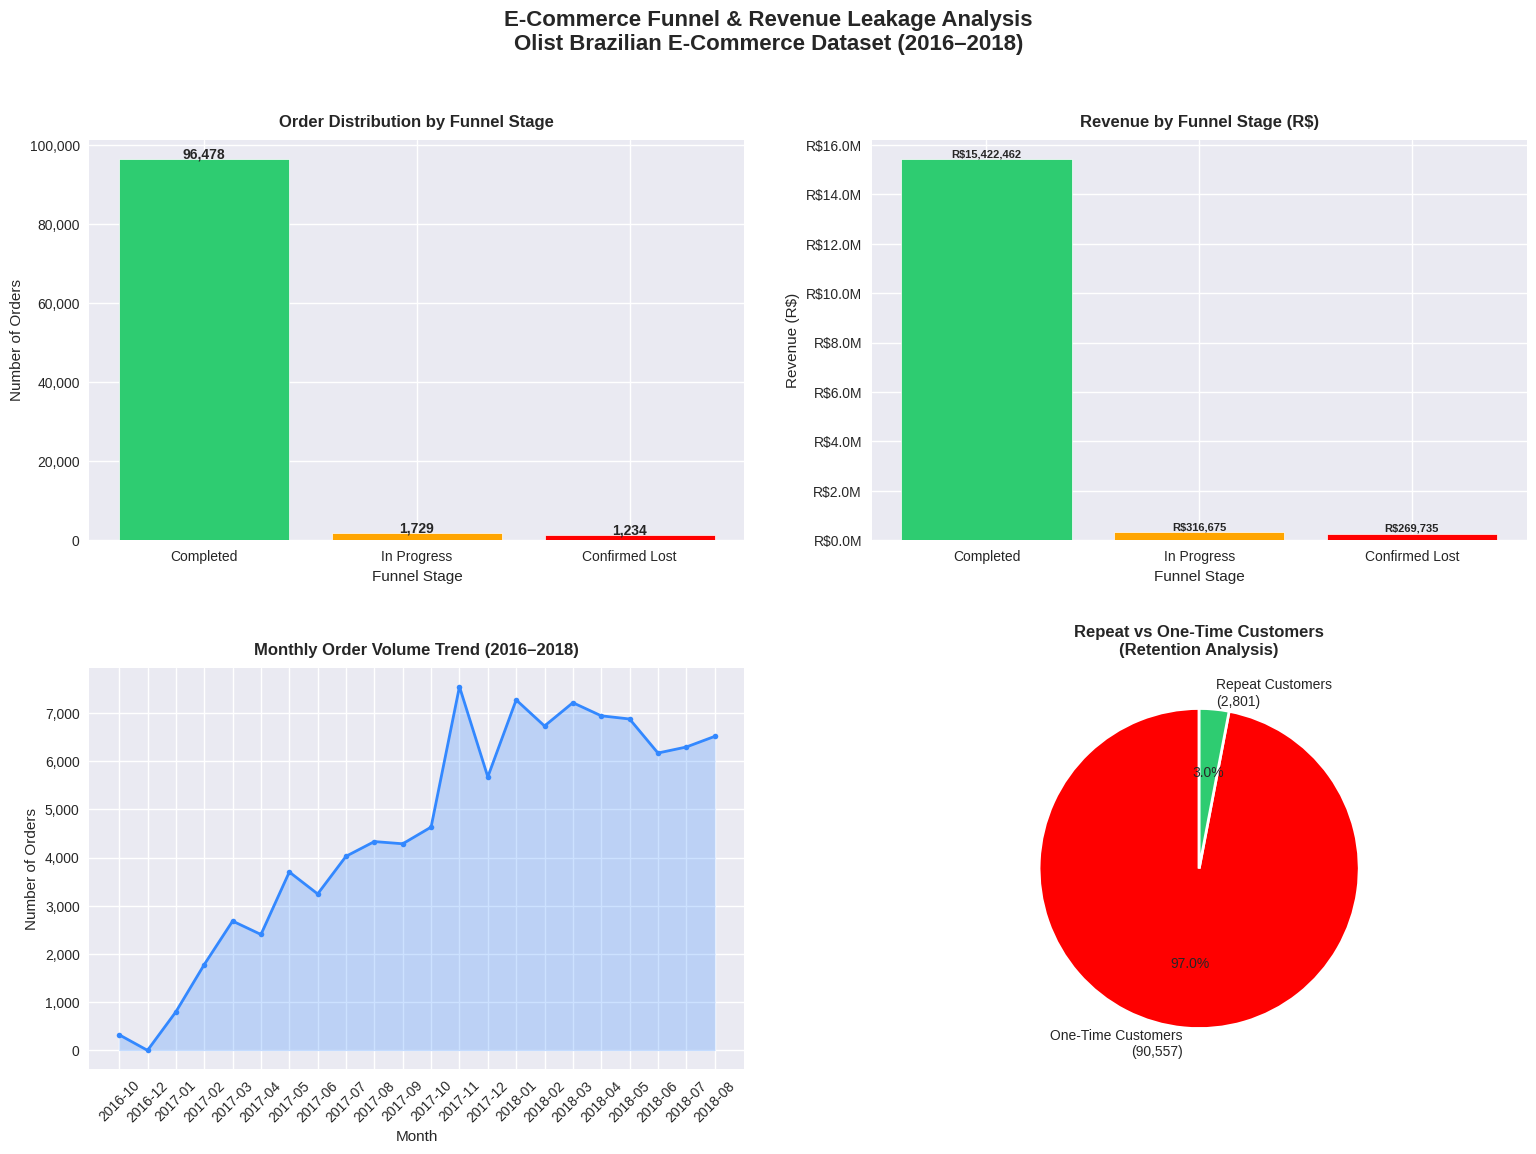

Charts saved successfully!


In [16]:
# Cell 14 — Project Visualisations
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    'E-Commerce Funnel & Revenue Leakage Analysis\n'
    'Olist Brazilian E-Commerce Dataset (2016–2018)',
    fontsize=16, fontweight='bold'
)

# ---- Chart 1 — Funnel Stage Distribution ----
funnel_counts = df['funnel_stage'].value_counts()
colors1 = ['#2ecc71', '#ffa500', '#ff0000']
bars1 = axes[0,0].bar(
    funnel_counts.index,
    funnel_counts.values,
    color=colors1,
    edgecolor='white',
    linewidth=0.5
)
axes[0,0].set_title(
    'Order Distribution by Funnel Stage',
    fontweight='bold', pad=10
)
axes[0,0].set_xlabel('Funnel Stage')
axes[0,0].set_ylabel('Number of Orders')
axes[0,0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
for bar in bars1:
    height = bar.get_height()
    axes[0,0].text(
        bar.get_x() + bar.get_width()/2,
        height + 300,
        f'{int(height):,}',
        ha='center', fontweight='bold', fontsize=10
    )

# ---- Chart 2 — Revenue by Funnel Stage ----
revenue_labels = ['Completed', 'In Progress', 'Confirmed Lost']
revenue_values = [total_revenue,
                  inprogress_revenue,
                  lost_revenue]
colors2 = ['#2ecc71', '#ffa500', '#ff0000']
bars2 = axes[0,1].bar(
    revenue_labels,
    revenue_values,
    color=colors2,
    edgecolor='white',
    linewidth=0.5
)
axes[0,1].set_title(
    'Revenue by Funnel Stage (R$)',
    fontweight='bold', pad=10
)
axes[0,1].set_xlabel('Funnel Stage')
axes[0,1].set_ylabel('Revenue (R$)')
axes[0,1].yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f'R${x/1e6:.1f}M'
    )
)
for bar, val in zip(bars2, revenue_values):
    axes[0,1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 100000,
        f'R${val:,.0f}',
        ha='center', fontsize=8,
        fontweight='bold'
    )

# ---- Chart 3 — Monthly Order Trend ----
# Convert timestamp to datetime first
df['order_month'] = pd.to_datetime(
    df['order_purchase_timestamp']
).dt.to_period('M')

monthly_trend = df.groupby('order_month').agg(
    total_orders=('order_id', 'count'),
    total_revenue=('total_payment', 'sum')
).reset_index()

monthly_trend['order_month'] = monthly_trend[
    'order_month'].astype(str)

# Remove first and last 2 months
# (incomplete data at dataset edges)
# Remove last 2 months — incomplete data at dataset end
monthly_trend = monthly_trend.iloc[1:-2]

axes[1,0].plot(
    monthly_trend['order_month'],
    monthly_trend['total_orders'],
    color='#3388ff',
    linewidth=2.0,
    marker='o',
    markersize=4
)
axes[1,0].fill_between(
    monthly_trend['order_month'],
    monthly_trend['total_orders'],
    alpha=0.25,
    color='#3488ff'
)
axes[1,0].set_title(
    'Monthly Order Volume Trend (2016–2018)',
    fontweight='bold', pad=10
)
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Number of Orders')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

# ---- Chart 4 — Repeat vs One-Time Customers ----
repeat_customers = customer_value[
    customer_value['total_orders'] > 1
]
one_time_customers = customer_value[
    customer_value['total_orders'] == 1
]

pie_labels = [
    f'One-Time Customers\n({len(one_time_customers):,})',
    f'Repeat Customers\n({len(repeat_customers):,})'
]
pie_values = [
    len(one_time_customers),
    len(repeat_customers)
]
pie_colors = ['#ff0000', '#2ecc71']
axes[1,1].pie(
    pie_values,
    labels=pie_labels,
    colors=pie_colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 10}
)
axes[1,1].set_title(
    'Repeat vs One-Time Customers\n'
    '(Retention Analysis)',
    fontweight='bold', pad=10
)

plt.tight_layout(pad=3.0)
plt.savefig('ecommerce_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved successfully!")

In [17]:
# Cell 15 — Business Insights & Recommendations Summary

print("=" * 60)
print("   BUSINESS INSIGHTS & RECOMMENDATIONS SUMMARY")
print("=" * 60)

print(f"""
DATASET OVERVIEW
----------------
Total Orders Analysed:      {len(df):,}
Time Period:                2016 – 2018
Total Potential Revenue:    R$ {total_potential:,.2f}
Unique Customers:           {len(customer_value):,}

FUNNEL ANALYSIS
---------------
Overall Conversion Rate:    96.34%
Confirmed Lost Orders:      {len(confirmed_lost):,} orders
Confirmed Revenue Leakage:  R$ {lost_revenue:,.2f} (1.68%)
At-Risk Revenue:            R$ {inprogress_revenue:,.2f} (1.98%)

KEY INSIGHTS
------------
1. Revenue leakage of R$269,735 across 1,234 lost orders
   — cancellations and unavailability are primary drivers
   — operational failures, not customer behaviour

2. Lost orders had avg value of R$218 vs R$160 completed
   — high-value transactions failing disproportionately
   — checkout friction likely higher for expensive items

3. Repeat purchase rate of just 3.23% across 93,358 customers
   — retention is a critical gap
   — acquiring new customers costs 5-7x more than retaining

4. Business grew 25x from 300 to 7,500 orders/month
   — peak in Nov 2017 (Black Friday effect)
   — stabilised at ~6,500/month through 2018

5. Top 4.6% of customers (High segment) drive 25.5% revenue
   — average spend of R$923 per VIP customer
   — losing even 10% of this segment = R$393,763 lost

RECOMMENDATIONS
---------------
1. IMMEDIATE — Fix cancellation root causes
   Audit checkout UX and payment gateway reliability
   Target: reduce cancellation rate by 50%
   Estimated recovery: R$134,000+

2. SHORT TERM — VIP retention programme
   Identify and personally engage 4,265 high-value customers
   Loyalty rewards, priority support, early access
   Estimated impact: protect R$3.9M revenue base

3. MEDIUM TERM — Improve repeat purchase rate
   Email re-engagement campaigns for one-time buyers
   Target: move repeat rate from 3.23% to 6%
   Impact: ~2,800 additional orders annually

4. LONG TERM — Inventory management overhaul
   609 unavailable orders = seller-side fulfilment failure
   Implement seller performance scoring system
""")

print("=" * 60)
print("   END OF ANALYSIS")
print("=" * 60)

   BUSINESS INSIGHTS & RECOMMENDATIONS SUMMARY

DATASET OVERVIEW
----------------
Total Orders Analysed:      99,441
Time Period:                2016 – 2018
Total Potential Revenue:    R$ 16,008,872.12
Unique Customers:           93,358

FUNNEL ANALYSIS
---------------
Overall Conversion Rate:    96.34%
Confirmed Lost Orders:      1,234 orders
Confirmed Revenue Leakage:  R$ 269,735.11 (1.68%)
At-Risk Revenue:            R$ 316,675.24 (1.98%)

KEY INSIGHTS
------------
1. Revenue leakage of R$269,735 across 1,234 lost orders
   — cancellations and unavailability are primary drivers
   — operational failures, not customer behaviour

2. Lost orders had avg value of R$218 vs R$160 completed
   — high-value transactions failing disproportionately
   — checkout friction likely higher for expensive items

3. Repeat purchase rate of just 3.23% across 93,358 customers
   — retention is a critical gap
   — acquiring new customers costs 5-7x more than retaining

4. Business grew 25x from 300 to 7

In [19]:
# Cell 16 — Save Clean Dataset & Final Confirmation

# Save master table for reproducibility
df.to_csv('olist_master_clean.csv', index=False)

# Final confirmation
print("=== PROJECT COMPLETE ===")
print(f"Clean dataset saved: olist_master_clean.csv")
print(f"Charts saved: ecommerce_analysis.png")
print(f"\nNotebook: Ecommerce_Funnel_Analysis")
print(f"Dataset: Olist Brazilian E-Commerce (Kaggle)")
print(f"Author: Abhishek Gajanan Kale")
print(f"\nFiles ready for GitHub deployment:")
print(f"  1. Ecommerce_Funnel_Analysis.ipynb")
print(f"  2. ecommerce_analysis.png")
print(f"  3. olist_master_clean.csv")
print(f"  4. README.md ")

=== PROJECT COMPLETE ===
Clean dataset saved: olist_master_clean.csv
Charts saved: ecommerce_analysis.png

Notebook: Ecommerce_Funnel_Analysis
Dataset: Olist Brazilian E-Commerce (Kaggle)
Author: Abhishek Gajanan Kale

Files ready for GitHub deployment:
  1. Ecommerce_Funnel_Analysis.ipynb
  2. ecommerce_analysis.png
  3. olist_master_clean.csv
  4. README.md 
